# **Assignment 3: MLP Design and Optimization for CIFAR-10 (Part B)**

## **Problem Statement**

Design and optimize a Multi-Layer Perceptron (MLP) classifier to achieve optimal performance on the CIFAR-10 image dataset using heuristic hyperparameter tuning.

## **Dataset**

The CIFAR-10 dataset contains 60,000 32x32 color images in 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, and truck). The dataset is split into 50,000 training images and 10,000 test images.

### **Description:**

- Images are small 32x32 pixels with 3 color channels.
- The task is multi-class classification across 10 categories.

### **Source:**

Dataset is available directly from the Keras API: `tf.keras.datasets.cifar10`

### **Input variables:**

- Image pixel data represented as a 4D tensor (batch_size, 32, 32, 3)
- Pixel intensities scaled between 0 and 1 after preprocessing

### **Output variable:**

- Integer class labels (0-9) corresponding to the image categories

#1. Setup: Import Libraries
This cell imports all necessary libraries:
- TensorFlow and Keras for building the MLP ,
- NumPy for data manipulation ,
- Matplotlib for plotting learning curves ,
- Scikit-Learn for performance metrics.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

#2. Load Dataset: CIFAR-10
As per the assignment instructions, the CIFAR-10 dataset was loaded directly using the Keras API. This dataset is already split into 50,000 training images and 10,000 test images

In [2]:
print("Loading CIFAR-10 dataset...")
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"X_train_full shape: {X_train_full.shape}")
print(f"y_train_full shape: {y_train_full.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 49s 0us/step
X_train_full shape: (50000, 32, 32, 3)
y_train_full shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


#3. Data Pre-processing
This cell performs three critical pre-processing steps as required by the assignment:

- **Validation Set**: The full training data (50,000 samples) was split into a smaller training set (45,000) and a validation set (5,000). This is a best practice for monitoring overfitting and for use with Early Stopping.

- **Scale Features**: Min-max scaling applied by dividing all pixel values (originally 0-255) by 255.0 to normalize them to a [0, 1] range.


- **Ravel Labels**: The Keras dataset loads labels as 2D column vectors (e.g., (50000, 1)). We convert them to 1D arrays (e.g., (50000,)) using numpy.ravel(), as instructed.

In [3]:
print("Creating validation split...")
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print("Scaling data (Min-Max Scaling)...")
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0

print("Raveling labels...")
y_train = y_train.ravel()
y_valid = y_valid.ravel()
y_test = y_test.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Creating validation split...
Scaling data (Min-Max Scaling)...
Raveling labels...
X_train shape: (45000, 32, 32, 3)
y_train shape: (45000,)
X_valid shape: (5000, 32, 32, 3)
y_valid shape: (5000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


#4. Define Class Names
A list of the 10 class names were created for CIFAR-10. This will be used later to make the Classification Report more readable.

In [4]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

#5. Build the Optimal MLP Model
This is the core design from Experiment 12. Based on heuristics (detailed in Q-7), we design a deep MLP optimized for CIFAR-10.

- Heuristic 1 (Architecture): CIFAR-10 is complex, so I used a deeper network than the MNIST example. I have used 3 hidden layers with a decreasing number of neurons (512 -> 256 -> 128) to capture hierarchical features.

- Heuristic 2 (Input Layer): I used Flatten to unroll the 32x32x3 color images into a 1D vector (3072 features).

- Heuristic 3 (Activation/Initializer): I used the 'relu' activation function and 'he_normal' weight initializer, which are standard practice for deep networks to prevent vanishing gradients.

- Heuristic 4 (Regularization): To combat severe overfitting, I used a combination of:
1. L2 Regularization (Weight Decay): kernel_regularizer=tf.keras.regularizers. l2(0.0001) is added to each Dense layer.
2. Dropout: Dropout(0.3) is added after each hidden layer to randomly deactivate neurons during training.

- Heuristic 5 (Output Layer): I used a 10-neuron Dense layer with 'softmax' activation for multi-class classification.

In [5]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.models.Sequential(name="Optimal_MLP_CIFAR10")
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))

# Hidden Layer 1
model.add(tf.keras.layers.Dense(units=512, activation="relu", kernel_initializer="he_normal",
                             kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(tf.keras.layers.Dropout(rate=0.3))

# Hidden Layer 2
model.add(tf.keras.layers.Dense(units=256, activation="relu", kernel_initializer="he_normal",
                             kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(tf.keras.layers.Dropout(rate=0.3))

# Hidden Layer 3
model.add(tf.keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal",
                             kernel_regularizer=tf.keras.regularizers.l2(0.0001)))
model.add(tf.keras.layers.Dropout(rate=0.3))

# Output Layer
model.add(tf.keras.layers.Dense(units=10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Optimal_MLP_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

#6. Compile the Model

- Loss: 'sparse_categorical_crossentropy' is used because my labels (y_train) are integers (not one-hot encoded).
- Optimizer: I used Stochastic Gradient Descent (SGD) as specified. A standard heuristic for improving SGD is to add momentum (e.g., 0.9) and used a modest learning rate (e.g., 0.01).

- Metrics: I monitored 'accuracy'.

In [6]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

#7. Define Callbacks
I implemented Early Stopping as a regularization technique. This monitors the val_loss and stops training if it doesn't improve for 10 consecutive epochs (patience=10). restore_best_weights=True ensures the model reverts to the weights from the epoch with the best validation loss

In [7]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#8. Train the Model
The model was trained using fit()

- Epochs: I had set a high number (100) and let Early Stopping find the optimal stopping point.

- Batch Size: I used a batch_size of 64, a common heuristic value.

- Validation Data: Validation set to monitor performance on unseen data during training.


- Callbacks: early_stopping_cb was included

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.1859 - loss: 2.3550 - val_accuracy: 0.3194 - val_loss: 2.0678
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2719 - loss: 2.1518 - val_accuracy: 0.3538 - val_loss: 1.9906
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3016 - loss: 2.0819 - val_accuracy: 0.3608 - val_loss: 1.9472
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3166 - loss: 2.0339 - val_accuracy: 0.3640 - val_loss: 1.9237
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3326 - loss: 1.9976 - val_accuracy: 0.3726 - val_loss: 1.9033
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3370 - loss: 1.9727 - val_accuracy: 0.3920 - val_loss: 1.8688
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3496 - loss: 1.9437 - val_accuracy: 0.4166 - val_loss: 1.8267
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3572 - loss: 1.9321 - val_ac

#9. Evaluate Performance on Test Set
Now trained model on the 10,000-sample test was set. The predictions were obtaind and converted the probabilities (from softmax) into single class labels using np.argmax.

In [9]:
print("Evaluating model on test data...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Get predictions
y_pred_proba = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

# Get training accuracy
train_accuracy = history.history['accuracy'][-1]

Evaluating model on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


#10. Final Results (Metrics)
This cell provides the final deliverables for Experiment 12: training accuracy, test accuracy, confusion matrix, and classification report.

Final Training Accuracy: 0.5238
Final Test Accuracy:   0.5241

--- Test Confusion Matrix ---


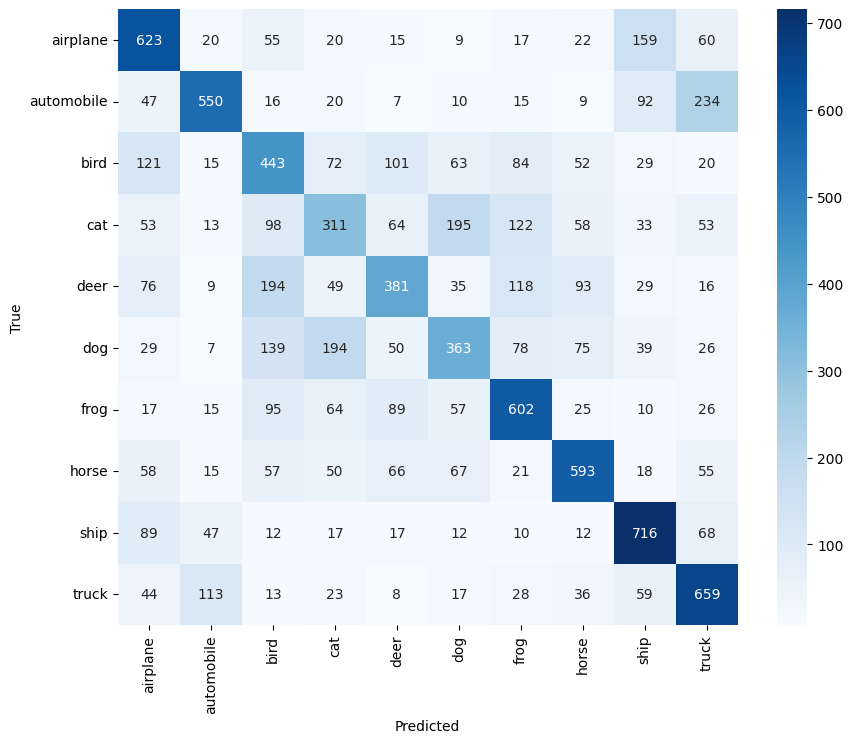


--- Test Classification Report ---
              precision    recall  f1-score   support

    airplane       0.54      0.62      0.58      1000
  automobile       0.68      0.55      0.61      1000
        bird       0.39      0.44      0.42      1000
         cat       0.38      0.31      0.34      1000
        deer       0.48      0.38      0.42      1000
         dog       0.44      0.36      0.40      1000
        frog       0.55      0.60      0.57      1000
       horse       0.61      0.59      0.60      1000
        ship       0.60      0.72      0.66      1000
       truck       0.54      0.66      0.59      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



In [10]:
print(f"Final Training Accuracy: {train_accuracy:.4f}")
print(f"Final Test Accuracy:   {test_accuracy:.4f}\n")

print("--- Test Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\n--- Test Classification Report ---")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

#11. Final Results (Learning Curves)
The model's accuracy and loss for both training and validation sets over the epochs was plotted. This helps visualize overfitting and the effectiveness of our Early Stopping

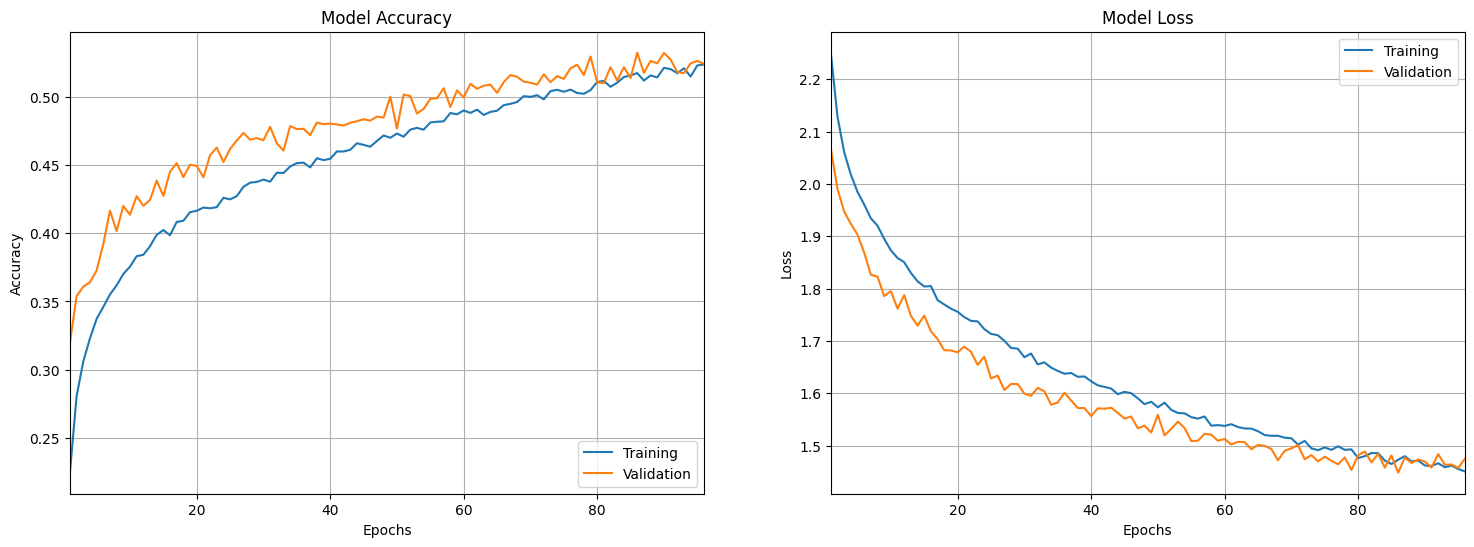

In [11]:
numOfEpochs = len(history.history['loss'])

plt.figure(figsize=(18, 6))

# Plot Accuracy
plt.subplot(121)
plt.plot(range(1, numOfEpochs + 1), history.history['accuracy'], label='Training')
plt.plot(range(1, numOfEpochs + 1), history.history['val_accuracy'], label='Validation')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xlim([1, numOfEpochs])
plt.grid(True)

# Plot Loss
plt.subplot(122)
plt.plot(range(1, numOfEpochs + 1), history.history['loss'], label='Training')
plt.plot(range(1, numOfEpochs + 1), history.history['val_loss'], label='Validation')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim([1, numOfEpochs])
plt.grid(True)

plt.show()